In [1]:
import numpy as np

from matplotlib import pyplot as plt

from npkwt import NPKWTDiscrete, NPKWTDiscreteLimited

In [2]:
# PMFs of distributions under H0 and H1
p0 = np.array([2/3, 1/3])
p1 = np.array([1/3, 2/3])

In [3]:
# Approximate test on integer-valued log_z grid
log_z_grid = np.arange(-40, 41)

### Limited Randomness Case

In [4]:
# Use at most 10 randomized stopping rules
k = 10
# Use 10 points per unit interval for c grid (dc = 0.1)
c_ppui = 10

In [5]:
# Initialize and solve NPKWT, use base 2 for log-likelihood ratio
npkwt_bernoulli_limited = NPKWTDiscreteLimited(k, p0, p1, 2)
npkwt_bernoulli_limited.setup(log_z_grid, c_ppui)

Solving k = 1
Solving k = 2
Solving k = 3
Solving k = 4
Solving k = 5
Solving k = 6
Solving k = 7
Solving k = 8
Solving k = 9
Solving k = 10


### Unlimited Randomness Case

In [6]:
# Initialize and solve NPKWT, use base 2 for log-likelihood ratio
npkwt_bernoulli = NPKWTDiscrete(p0, p1, 2)
npkwt_bernoulli.setup(log_z_grid)

Iteration 1: diff = 0.3633762271766865
Iteration 2: diff = 0.030650688536595472
Iteration 3: diff = 0.009244375783027614
Iteration 4: diff = 0.003998745851613916
Iteration 5: diff = 0.002153563911293066
Iteration 6: diff = 0.001269239610746764
Iteration 7: diff = 0.0008093470365640454
Iteration 8: diff = 0.0005537095301417772
Iteration 9: diff = 0.0003851055249705082
Iteration 10: diff = 0.00028151156250127984
Iteration 11: diff = 0.00020965063848255028
Iteration 12: diff = 0.0001572725119275975
Iteration 13: diff = 0.00012054648251530464
Iteration 14: diff = 9.564527944744272e-05
Iteration 15: diff = 7.492240190187793e-05
Iteration 16: diff = 6.085944494793605e-05
Iteration 17: diff = 4.985668573365132e-05
Iteration 18: diff = 4.0794058526194554e-05
Iteration 19: diff = 3.2934722088096e-05
Iteration 20: diff = 2.6544561544106227e-05
Iteration 21: diff = 2.1325521572357342e-05
Iteration 22: diff = 1.711406227178358e-05
Iteration 23: diff = 1.3933004456179177e-05
Iteration 24: diff = 1.

### Figure 1

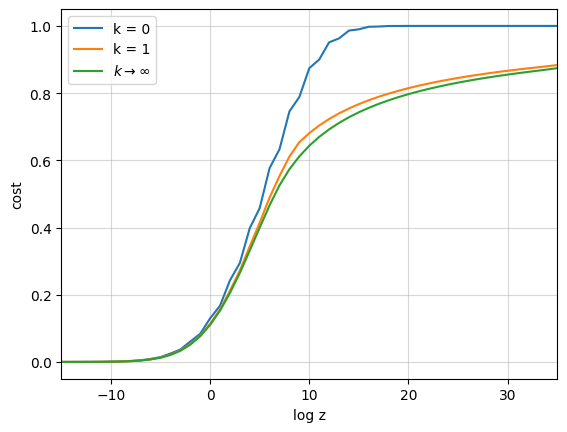

In [7]:
plt.plot(log_z_grid, npkwt_bernoulli_limited.rho(0, log_z_grid, 20), label="k = 0")
plt.plot(log_z_grid, npkwt_bernoulli_limited.rho(1, log_z_grid, 20), label="k = 1")
plt.plot(log_z_grid, npkwt_bernoulli.rho(log_z_grid, 20), label=r"$k \to \infty$")
plt.xlim(-15, 35)
plt.xlabel("log z")
plt.ylabel("cost")
plt.legend()
plt.grid(alpha=0.5)

### Figure 2

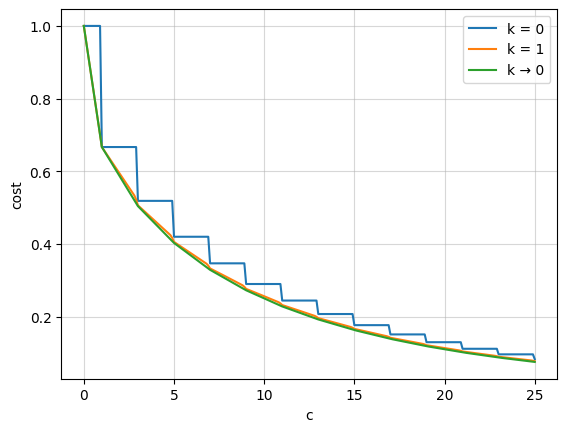

In [8]:
c_grid = np.linspace(0, 25, 251)
plt.plot(c_grid, npkwt_bernoulli_limited.rho(0, 0, c_grid), label="k = 0")
plt.plot(c_grid, npkwt_bernoulli_limited.rho(1, 0, c_grid), label="k = 1")
plt.plot(c_grid, npkwt_bernoulli.rho(0, c_grid), label="k → 0")
plt.xlabel("c")
plt.ylabel("cost")
plt.legend()
plt.grid(alpha=0.5)

### Figure 3

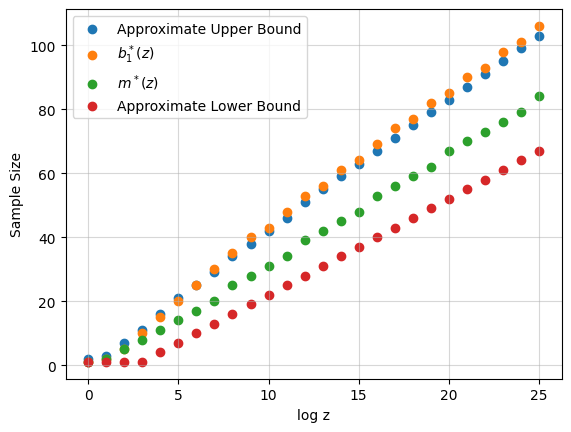

In [9]:
log_z_pos = np.arange(26)
plt.scatter(log_z_pos, [npkwt_bernoulli.m_star_ub(log_z) for log_z in log_z_pos], label="Approximate Upper Bound")
plt.scatter(log_z_pos, [npkwt_bernoulli_limited.b_star(0, log_z) for log_z in log_z_pos], label=r"$b_1^*(z)$")
plt.scatter(log_z_pos, [npkwt_bernoulli.m_star(log_z) for log_z in log_z_pos], label=r"$m^*(z)$")
plt.scatter(log_z_pos, [npkwt_bernoulli.m_star_lb(log_z) for log_z in log_z_pos], label="Approximate Lower Bound")
plt.xlabel("log z")
plt.ylabel("Sample Size")
plt.legend()
plt.grid(alpha=0.5)

### Figure 4

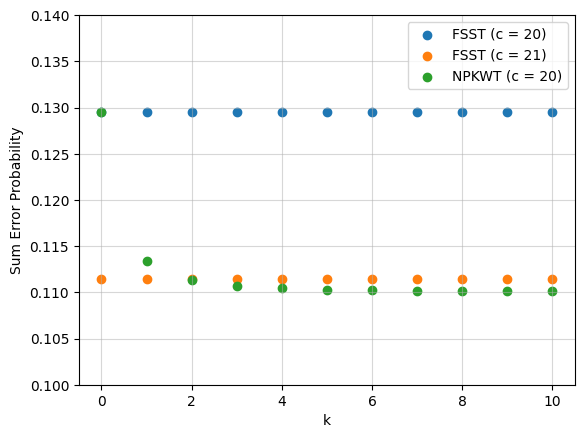

In [10]:
plt.scatter(np.arange(11), [npkwt_bernoulli_limited.rho(0, 0, 20) for _ in range(11)], label="FSST (c = 20)")
plt.scatter(np.arange(11), [npkwt_bernoulli_limited.rho(0, 0, 21) for _ in range(11)], label="FSST (c = 21)")
plt.scatter(np.arange(11), [npkwt_bernoulli_limited.rho(k, 0, 20) for k in range(11)], label="NPKWT (c = 20)")
plt.xlabel("k")
plt.ylabel("Sum Error Probability")
plt.ylim(0.1, 0.14)
plt.legend()
plt.grid(alpha=0.5)

### Figure 5

In [11]:
# Simulate 10,000 runs (this will take some time, consider reducing the number for a quick glance...)
D, T, N_rand = npkwt_bernoulli.simulate(0, 20, p0, 10000)

100%|██████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [04:25<00:00, 37.67it/s]


Text(0, 0.5, 'Density')

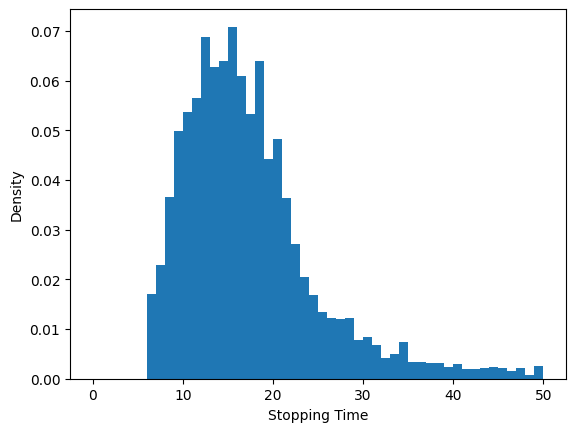

In [12]:
plt.hist(T, bins=np.arange(51), density=True)
plt.xlabel("Stopping Time")
plt.ylabel("Density")

### Figure 6

Text(0, 0.5, 'Density')

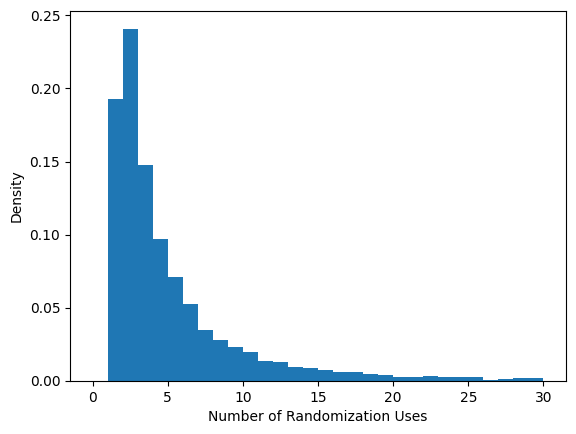

In [13]:
plt.hist(N_rand, bins=np.arange(31), density=True)
plt.xlabel("Number of Randomization Uses")
plt.ylabel("Density")